# HandReachDense — PPO

Capítulos 1–5. El informe del capítulo 6 y la ejecución real en Colab quedan pendientes de la entrega académica.

## Capítulo 1 — Librerías, bootstrap y variables transversales

Python 3.12. Instalación solo en Colab; entorno local aislado preparado según README. Pins verificados localmente, sin afirmar validación Colab.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
DEPENDENCIES = {
    "gymnasium-robotics": "1.4.2", "gymnasium": "1.3.0", "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0", "torch": "2.14.0", "numpy": "2.5.3",
    "pandas": "3.0.5", "matplotlib": "3.11.2", "pillow": "12.3.0",
    "imageio": "2.37.4", "imageio-ffmpeg": "0.6.0",
}
if IN_COLAB:
    os.environ["MUJOCO_GL"] = "egl"
    subprocess.check_call([sys.executable, "-m", "pip", "install", *[
        f"{name}=={version}" for name, version in DEPENDENCIES.items()
    ]])


In [2]:
import hashlib
import importlib.metadata
import json
import platform
import random
import time
from datetime import datetime, timezone

import gymnasium as gym
import gymnasium_robotics
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageDraw, ImageFont
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor

gym.register_envs(gymnasium_robotics)
VERSIONS = {name: importlib.metadata.version(name) for name in DEPENDENCIES}
assert VERSIONS == DEPENDENCIES, (VERSIONS, DEPENDENCIES)
CONFIG = {
    "env_id": "HandReachDense-v3", "algorithm": "PPO", "policy": "MultiInputPolicy",
    "profile": "smoke", "train_seed": 42, "device": "cpu", "torch_threads": 1,
    "baseline_seeds": list(range(101, 111)), "tuning_seeds": list(range(201, 206)),
    "selection_seeds": list(range(201, 211)), "final_eval_seeds": list(range(1001, 1011)),
    "probe_seeds": list(range(5001, 5101)), "reload_seeds": [401, 402],
    "video_seed": 301, "intermediate_timesteps": 500_000, "video_fps": 25, "video_size": 480,
    "success_definition": "success_final", "target_success": 0.80,
    "eval_freq": 50_000, "checkpoint_freq": 100_000, "rolling_window": 100,
    "profiles": {"smoke": {"timesteps": 8_192}, "full": {"timesteps": 1_000_000}},
    "ppo": {"learning_rate": 3e-4, "n_steps": 2048, "batch_size": 256,
            "n_epochs": 10, "gamma": 0.99, "gae_lambda": 0.95, "clip_range": 0.2,
            "ent_coef": 0.0, "vf_coef": 0.5, "max_grad_norm": 0.5},
    "net_arch": {"pi": [256, 256], "vf": [256, 256]},
}
MODEL_FOLDER = "3-HandReachDense"
PROJECT_ROOT = Path("/content") if IN_COLAB else Path.cwd().resolve()
MODEL_ROOT = PROJECT_ROOT if PROJECT_ROOT.name == MODEL_FOLDER else PROJECT_ROOT / MODEL_FOLDER
MODEL_DIR = MODEL_ROOT / "models"
VIDEO_DIR = MODEL_ROOT / "videos"
RESULTS_DIR = MODEL_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
RUNS_DIR = MODEL_ROOT / "runs"
FINAL_MODEL = MODEL_DIR / "hand_reach_ppo.zip"
METADATA_PATH = FINAL_MODEL.with_suffix(".metadata.json")
for directory in (MODEL_DIR, VIDEO_DIR, RESULTS_DIR, FIGURES_DIR, RUNS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
random.seed(CONFIG["train_seed"])
np.random.seed(CONFIG["train_seed"])
torch.manual_seed(CONFIG["train_seed"])
torch.set_num_threads(CONFIG["torch_threads"])
print(json.dumps({"versions": VERSIONS, "python": platform.python_version(),
                  "platform": platform.platform(), "machine": platform.machine(),
                  "device": CONFIG["device"], "cuda": torch.cuda.is_available(),
                  "mps": torch.backends.mps.is_available()}, indent=2))


AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


{
  "versions": {
    "gymnasium-robotics": "1.4.2",
    "gymnasium": "1.3.0",
    "mujoco": "3.2.7",
    "stable-baselines3": "2.9.0",
    "torch": "2.14.0",
    "numpy": "2.5.3",
    "pandas": "3.0.5",
    "matplotlib": "3.11.2",
    "pillow": "12.3.0",
    "imageio": "2.37.4",
    "imageio-ffmpeg": "0.6.0"
  },
  "python": "3.12.13",
  "platform": "macOS-26.6.2-arm64-arm-64bit",
  "machine": "arm64",
  "device": "cpu",
  "cuda": false,
  "mps": true
}


{
  "environment_id": "HandReachDense-v3",
  "entry_point": "gymnasium_robotics.envs.shadow_dexterous_hand.reach:MujocoHandReachEnv",
  "max_episode_steps": 50,
  "action_space": "Box(-1.0, 1.0, (20,), float32)",
  "observation_space": "Dict('achieved_goal': Box(-inf, inf, (15,), float64), 'desired_goal': Box(-inf, inf, (15,), float64), 'observation': Box(-inf, inf, (63,), float64))",
  "n_substeps": 20,
  "timestep": 0.002,
  "dt": 0.04,
  "distance_threshold": 0.01,
  "relative_control": false,
  "reward_type": "dense",
  "actuators": 20,
  "qpos_count": 24,
  "qvel_count": 24,
  "actuator_ctrlrange": [
    [
      -0.489,
      0.14
    ],
    [
      -0.698,
      0.489
    ],
    [
      -0.349,
      0.349
    ],
    [
      0.0,
      1.571
    ],
    [
      0.0,
      1.571
    ],
    [
      -0.349,
      0.349
    ],
    [
      0.0,
      1.571
    ],
    [
      0.0,
      1.571
    ],
    [
      -0.349,
      0.349
    ],
    [
      0.0,
      1.571
    ],
    [
      0

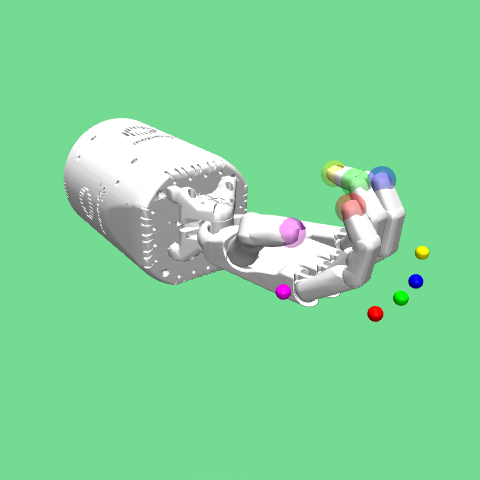

In [3]:
def make_env(seed, render=False):
    """Create the original environment and seed its spaces.

    Args:
        seed: Seed for environment and action/observation spaces.
        render: Whether to enable RGB rendering.

    Returns:
        A seeded Gymnasium environment with its original TimeLimit.
    """
    env = gym.make(CONFIG["env_id"], render_mode="rgb_array" if render else None,
                   width=CONFIG["video_size"], height=CONFIG["video_size"])
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    env.reset(seed=seed)
    return env


def write_json(path, value):
    """Write an inspectable JSON artifact.

    Args:
        path: Destination path.
        value: JSON-serializable data.
    """
    Path(path).write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")


probe = make_env(CONFIG["train_seed"], render=True)
try:
    obs, _ = probe.reset(seed=CONFIG["train_seed"])
    raw = probe.unwrapped
    assert probe.action_space.shape == (20,)
    assert {k: v.shape for k, v in obs.items()} == {"observation": (63,), "achieved_goal": (15,), "desired_goal": (15,)}
    assert (raw.model.nq, raw.model.nv, raw.model.nu) == (24, 24, 20)
    np.testing.assert_allclose(obs["observation"][:24], raw.data.qpos)
    np.testing.assert_allclose(obs["observation"][24:48], raw.data.qvel)
    np.testing.assert_allclose(obs["observation"][48:], obs["achieved_goal"])
    assert not raw.relative_control and raw.reward_type == "dense"
    assert raw.n_substeps == 20 and np.isclose(raw.model.opt.timestep, 0.002)
    assert np.isclose(raw.dt, 0.04) and probe.spec.max_episode_steps == 50
    assert np.isclose(raw.distance_threshold, 0.01)
    goals, initial_count, fingers = [], 0, set()
    for seed in CONFIG["probe_seeds"]:
        obs, _ = probe.reset(seed=seed)
        goals.append(obs["desired_goal"].copy())
        changed = np.linalg.norm((obs["desired_goal"] - raw.initial_goal).reshape(5, 3), axis=1) > 1e-10
        if not changed.any():
            initial_count += 1
        else:
            assert changed[-1] and changed.sum() == 2
            fingers.add(int(np.flatnonzero(changed[:4])[0]))
    assert 0 < initial_count < len(goals) and fingers == {0, 1, 2, 3}
    first, _ = probe.reset(seed=CONFIG["train_seed"])
    second, _ = probe.reset(seed=CONFIG["train_seed"])
    np.testing.assert_array_equal(first["desired_goal"], second["desired_goal"])
    for step in range(1, 51):
        obs, reward, terminated, truncated, info = probe.step(probe.action_space.sample())
        distance = np.linalg.norm(obs["achieved_goal"] - obs["desired_goal"])
        assert np.isfinite(reward) and np.isclose(reward, -distance, atol=1e-6)
        assert bool(info["is_success"] > 0.5) == bool(distance < 0.01)
        assert not terminated and truncated == (step == 50)
    frame = probe.render()
    assert frame.shape == (CONFIG["video_size"], CONFIG["video_size"], 3)
    contract = {"environment_id": probe.spec.id, "entry_point": probe.spec.entry_point,
                "max_episode_steps": probe.spec.max_episode_steps,
                "action_space": str(probe.action_space), "observation_space": str(probe.observation_space),
                "n_substeps": raw.n_substeps, "timestep": raw.model.opt.timestep, "dt": raw.dt,
                "distance_threshold": raw.distance_threshold, "relative_control": raw.relative_control,
                "reward_type": raw.reward_type, "actuators": raw.model.nu,
                "qpos_count": raw.model.nq, "qvel_count": raw.model.nv,
                "actuator_ctrlrange": raw.model.actuator_ctrlrange.tolist(),
                "goal_probe": {"count": len(goals), "initial_goal_count": initial_count,
                               "selected_fingers": sorted(fingers), "seeds": CONFIG["probe_seeds"]},
                "versions": VERSIONS, "python": platform.python_version(),
                "execution_target": "colab" if IN_COLAB else "local",
                "reward_success_horizon_pass": True, "render_shape": list(frame.shape)}
    write_json(RESULTS_DIR / "runtime_contract.json", contract)
    print(json.dumps(contract, indent=2))
    display(Image.fromarray(frame))
finally:
    probe.close()


## Capítulo 2 — Definición del agente

Pendiente de la tarea correspondiente.

## Capítulo 3 — Construcción y ejecución del entrenamiento

Pendiente de la tarea correspondiente.

## Capítulo 4 — Métricas y gráficas

Pendiente de la tarea correspondiente.

## Capítulo 5 — Videos

Pendiente de la tarea correspondiente.